# 📓 Notebook 06 – Model Evaluation
## Lettuce Fresh Weight Prediction | ANN + PSO

**Mode: Local (VS Code)**

Evaluasi komprehensif:
1. Perbandingan ANN vs ANN+PSO
2. 5-Fold Cross Validation (MAE±std, RMSE±std, R²±std, MAPE±std)
3. Residual Analysis
4. Prediksi per sampel
5. Ringkasan final

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os, joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.rcParams.update({
    'figure.facecolor': '#1a1a2e', 'axes.facecolor': '#16213e',
    'axes.labelcolor': 'white', 'xtick.color': 'white',
    'ytick.color': 'white', 'text.color': 'white',
    'axes.edgecolor': '#0f3460', 'grid.color': '#0f3460', 'axes.grid': True,
})
print('✅ Libraries loaded!')

✅ Libraries loaded!


In [3]:
BASE_DIR = r'D:/laragon/www/lettuce-weight-prediction'

df = pd.read_csv(f'{BASE_DIR}/data/dataset.csv')

FEATURE_COLUMNS = [
    'leaf_area', 'perimeter', 'aspect_ratio', 'extent', 'equivalent_diameter',
    'mean_R', 'mean_G', 'mean_B', 'mean_H', 'mean_S', 'mean_V', 'std_G',
    'contrast', 'energy', 'homogeneity', 'correlation', 'entropy'
]

X = df[FEATURE_COLUMNS].values
y = df['weight_gram'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler    = MinMaxScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# Load model
model_base_path = f'{BASE_DIR}/output/models/ann_model.pkl'
model_pso_path  = f'{BASE_DIR}/output/models/ann_model_pso_optimized.pkl'

ann_base = joblib.load(model_base_path) if os.path.exists(model_base_path) else None
ann_pso  = joblib.load(model_pso_path)  if os.path.exists(model_pso_path)  else None

print(f'✅ Dataset   : {len(df)} sampel | {len(FEATURE_COLUMNS)} fitur')
print(f'✅ Base ANN  : {"Loaded" if ann_base else "Tidak ditemukan"}')
print(f'✅ PSO ANN   : {"Loaded" if ann_pso else "Tidak ditemukan"}')

✅ Dataset   : 200 sampel | 17 fitur
✅ Base ANN  : Loaded
✅ PSO ANN   : Loaded


## A. 5-Fold Cross Validation

In [4]:
def run_cv(model_params: dict, X_scaled, y_values, cv_folds=5, label='ANN'):
    """Jalankan K-Fold CV dan kembalikan metrics per fold."""
    kf      = KFold(n_splits=cv_folds, shuffle=True, random_state=42)
    results = []
    scaler_cv = MinMaxScaler()

    print(f'\n🔄 Cross Validation ({cv_folds}-Fold) – {label}')
    print(f'  {"Fold":>6} | {"MAE":>8} | {"RMSE":>8} | {"R²":>8} | {"MAPE":>8}')
    print(f'  {"-"*52}')

    for fold, (tr_i, val_i) in enumerate(kf.split(X_scaled), 1):
        Xtr, Xval = X_scaled[tr_i], X_scaled[val_i]
        ytr, yval = y_values[tr_i], y_values[val_i]

        m = MLPRegressor(**model_params, random_state=42)
        m.fit(Xtr, ytr)
        yp = m.predict(Xval)

        mae  = mean_absolute_error(yval, yp)
        rmse = np.sqrt(mean_squared_error(yval, yp))
        r2   = r2_score(yval, yp)
        mape = np.mean(np.abs((yval - yp) / (yval + 1e-10))) * 100

        results.append({'fold': fold, 'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE': mape})
        print(f'  {fold:>6} | {mae:>8.4f} | {rmse:>8.4f} | {r2:>8.4f} | {mape:>7.2f}%')

    df_r = pd.DataFrame(results)
    print(f'  {"-"*52}')
    for m in ['MAE','RMSE','R2','MAPE']:
        print(f'  {m:>6}: mean={df_r[m].mean():>8.4f} | std={df_r[m].std():>8.4f}')
    return df_r


# Params base ANN
base_params = dict(
    hidden_layer_sizes=(64, 32, 16), activation='relu', solver='adam',
    alpha=0.001, learning_rate_init=0.001, max_iter=300, early_stopping=True
)

# Params PSO ANN (ambil dari model jika ada)
if ann_pso is not None:
    pso_layers = ann_pso.hidden_layer_sizes
    pso_lr     = ann_pso.learning_rate_init
    pso_alpha  = ann_pso.alpha
    pso_params = dict(
        hidden_layer_sizes=pso_layers, activation='relu', solver='adam',
        alpha=pso_alpha, learning_rate_init=pso_lr, max_iter=300, early_stopping=True
    )
else:
    pso_params = base_params  # fallback


cv_base = run_cv(base_params, X_train_s, y_train, label='ANN (Base)')
cv_pso  = run_cv(pso_params,  X_train_s, y_train, label='ANN + PSO')


🔄 Cross Validation (5-Fold) – ANN (Base)
    Fold |      MAE |     RMSE |       R² |     MAPE
  ----------------------------------------------------
       1 |   3.2635 |   4.3651 |   0.4236 |   11.07%
       2 |   3.9934 |   4.8896 |   0.2873 |   13.38%
       3 |   4.6208 |   5.6830 |  -0.1986 |   16.20%
       4 |   5.9896 |   7.3656 |  -0.2314 |   22.04%
       5 |   5.2405 |   6.3033 |  -0.4192 |   14.86%
  ----------------------------------------------------
     MAE: mean=  4.6216 | std=  1.0599
    RMSE: mean=  5.7213 | std=  1.1806
      R2: mean= -0.0277 | std=  0.3629
    MAPE: mean= 15.5093 | std=  4.1155

🔄 Cross Validation (5-Fold) – ANN + PSO
    Fold |      MAE |     RMSE |       R² |     MAPE
  ----------------------------------------------------
       1 |   3.0858 |   3.5920 |   0.6097 |    9.70%
       2 |   2.8470 |   3.7579 |   0.5790 |    9.34%
       3 |   4.5033 |   6.1666 |  -0.4113 |   17.28%
       4 |   4.0510 |   5.0063 |   0.4311 |   14.08%
       5 |   

## B. Perbandingan ANN vs ANN+PSO


📊 PERBANDINGAN FINAL:
    Metric |       ANN Base |        ANN+PSO |  Peningkatan
  ----------------------------------------------------------
       MAE | 4.6216 ± 1.0599 | 4.0299 ± 1.1380 | ✅ +0.5916
      RMSE | 5.7213 ± 1.1806 | 5.0872 ± 1.4584 | ✅ +0.6342
        R2 | -0.0277 ± 0.3629 | 0.1003 ± 0.6147 | ✅ +0.1280
      MAPE | 15.5093 ± 4.1155 | 13.2441 ± 3.5851 | ✅ +2.2652


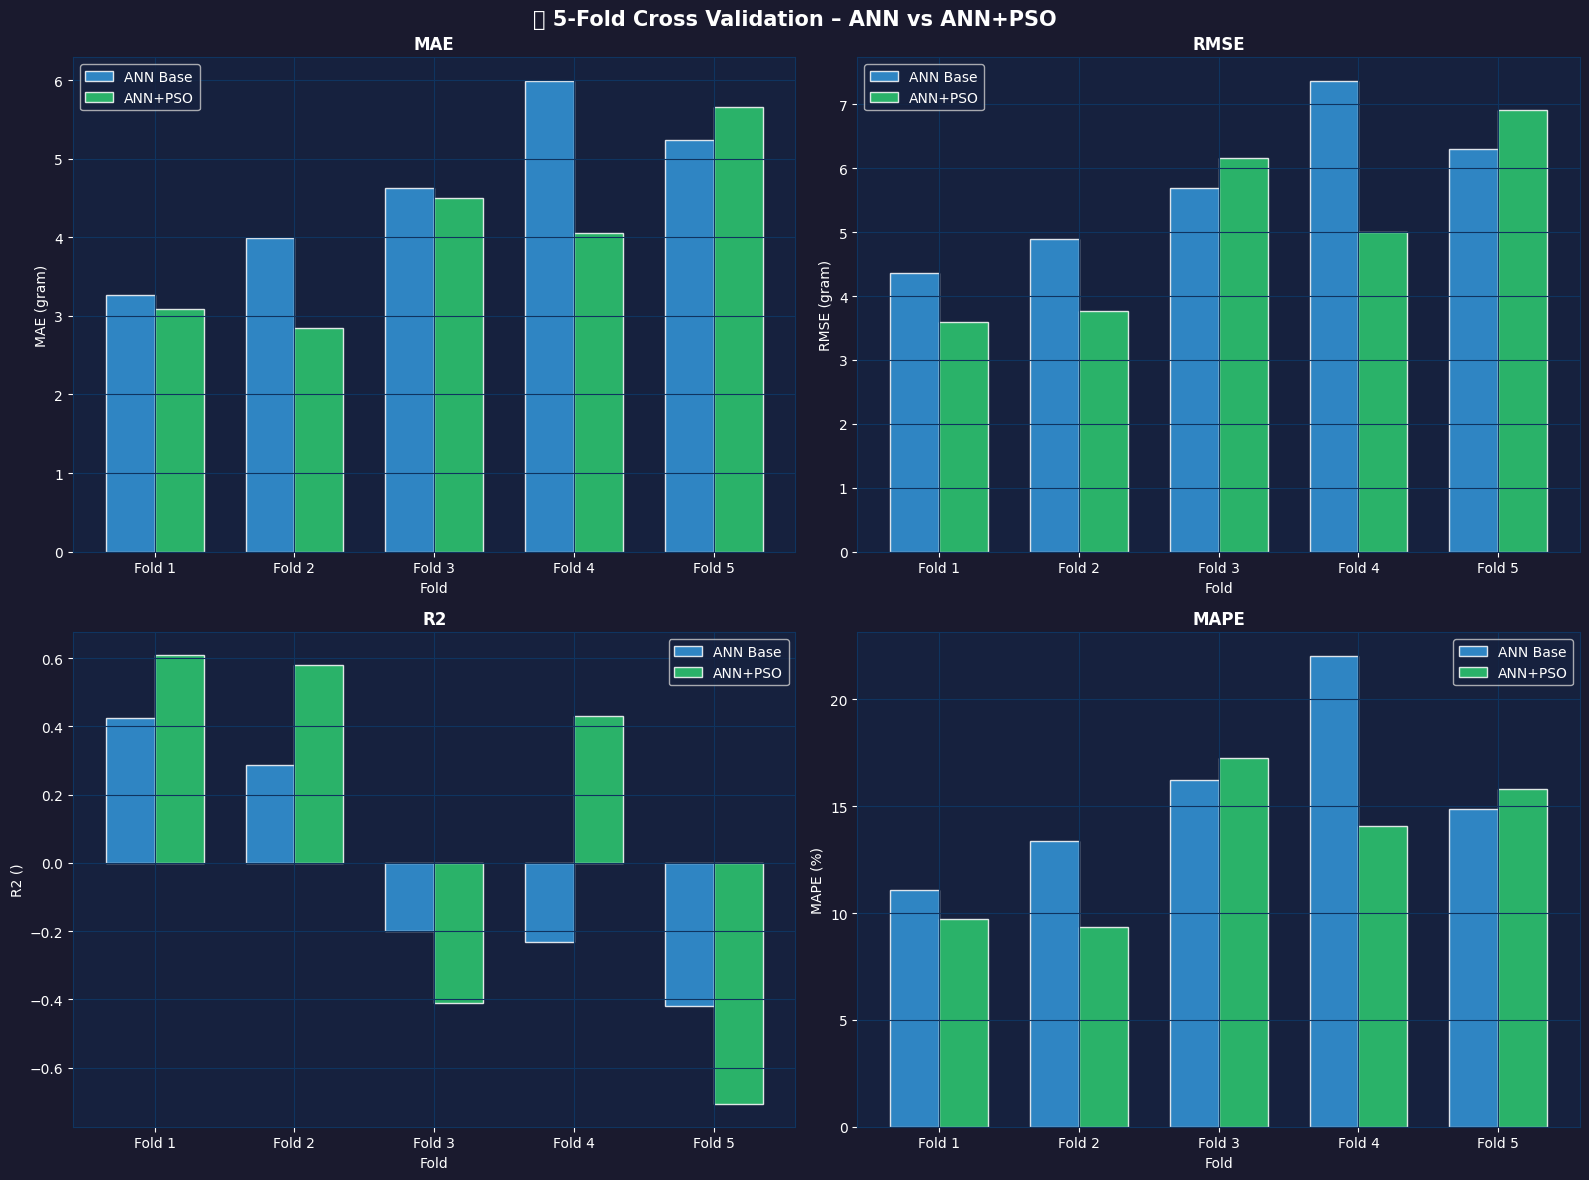

✅ Simpan → output/plots/cv_evaluation.png


In [5]:
metrics = ['MAE', 'RMSE', 'R2', 'MAPE']

print('\n📊 PERBANDINGAN FINAL:')
print(f'  {"Metric":>8} | {"ANN Base":>14} | {"ANN+PSO":>14} | {"Peningkatan":>12}')
print(f'  {"-"*58}')

for m in metrics:
    b = f'{cv_base[m].mean():.4f} ± {cv_base[m].std():.4f}'
    p = f'{cv_pso[m].mean():.4f} ± {cv_pso[m].std():.4f}'
    if m == 'R2':
        delta = cv_pso[m].mean() - cv_base[m].mean()
        sign  = '+' if delta > 0 else ''
        icon  = '✅' if delta > 0 else '🔴'
    else:
        delta = cv_base[m].mean() - cv_pso[m].mean()
        sign  = '+' if delta > 0 else ''
        icon  = '✅' if delta > 0 else '🔴'
    print(f'  {m:>8} | {b:>14} | {p:>14} | {icon} {sign}{delta:.4f}')

# Grafik per-fold
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('📊 5-Fold Cross Validation – ANN vs ANN+PSO', fontsize=15, fontweight='bold', color='white')

colors = ['#3498DB', '#2ECC71']
for ax, metric in zip(axes.flatten(), metrics):
    folds  = cv_base['fold'].values
    x      = np.arange(len(folds))
    w      = 0.35
    b1     = ax.bar(x - w/2, cv_base[metric], w, label='ANN Base', color=colors[0], alpha=0.85, edgecolor='white')
    b2     = ax.bar(x + w/2, cv_pso[metric],  w, label='ANN+PSO',  color=colors[1], alpha=0.85, edgecolor='white')
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_xlabel('Fold')
    ax.set_xticks(x); ax.set_xticklabels([f'Fold {f}' for f in folds])
    ax.legend()
    m_unit = 'gram' if metric in ['MAE','RMSE'] else ('%' if metric == 'MAPE' else '')
    ax.set_ylabel(f'{metric} ({m_unit})')

plt.tight_layout()
plt.savefig(f'{BASE_DIR}/output/plots/cv_evaluation.png', dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
print('✅ Simpan → output/plots/cv_evaluation.png')

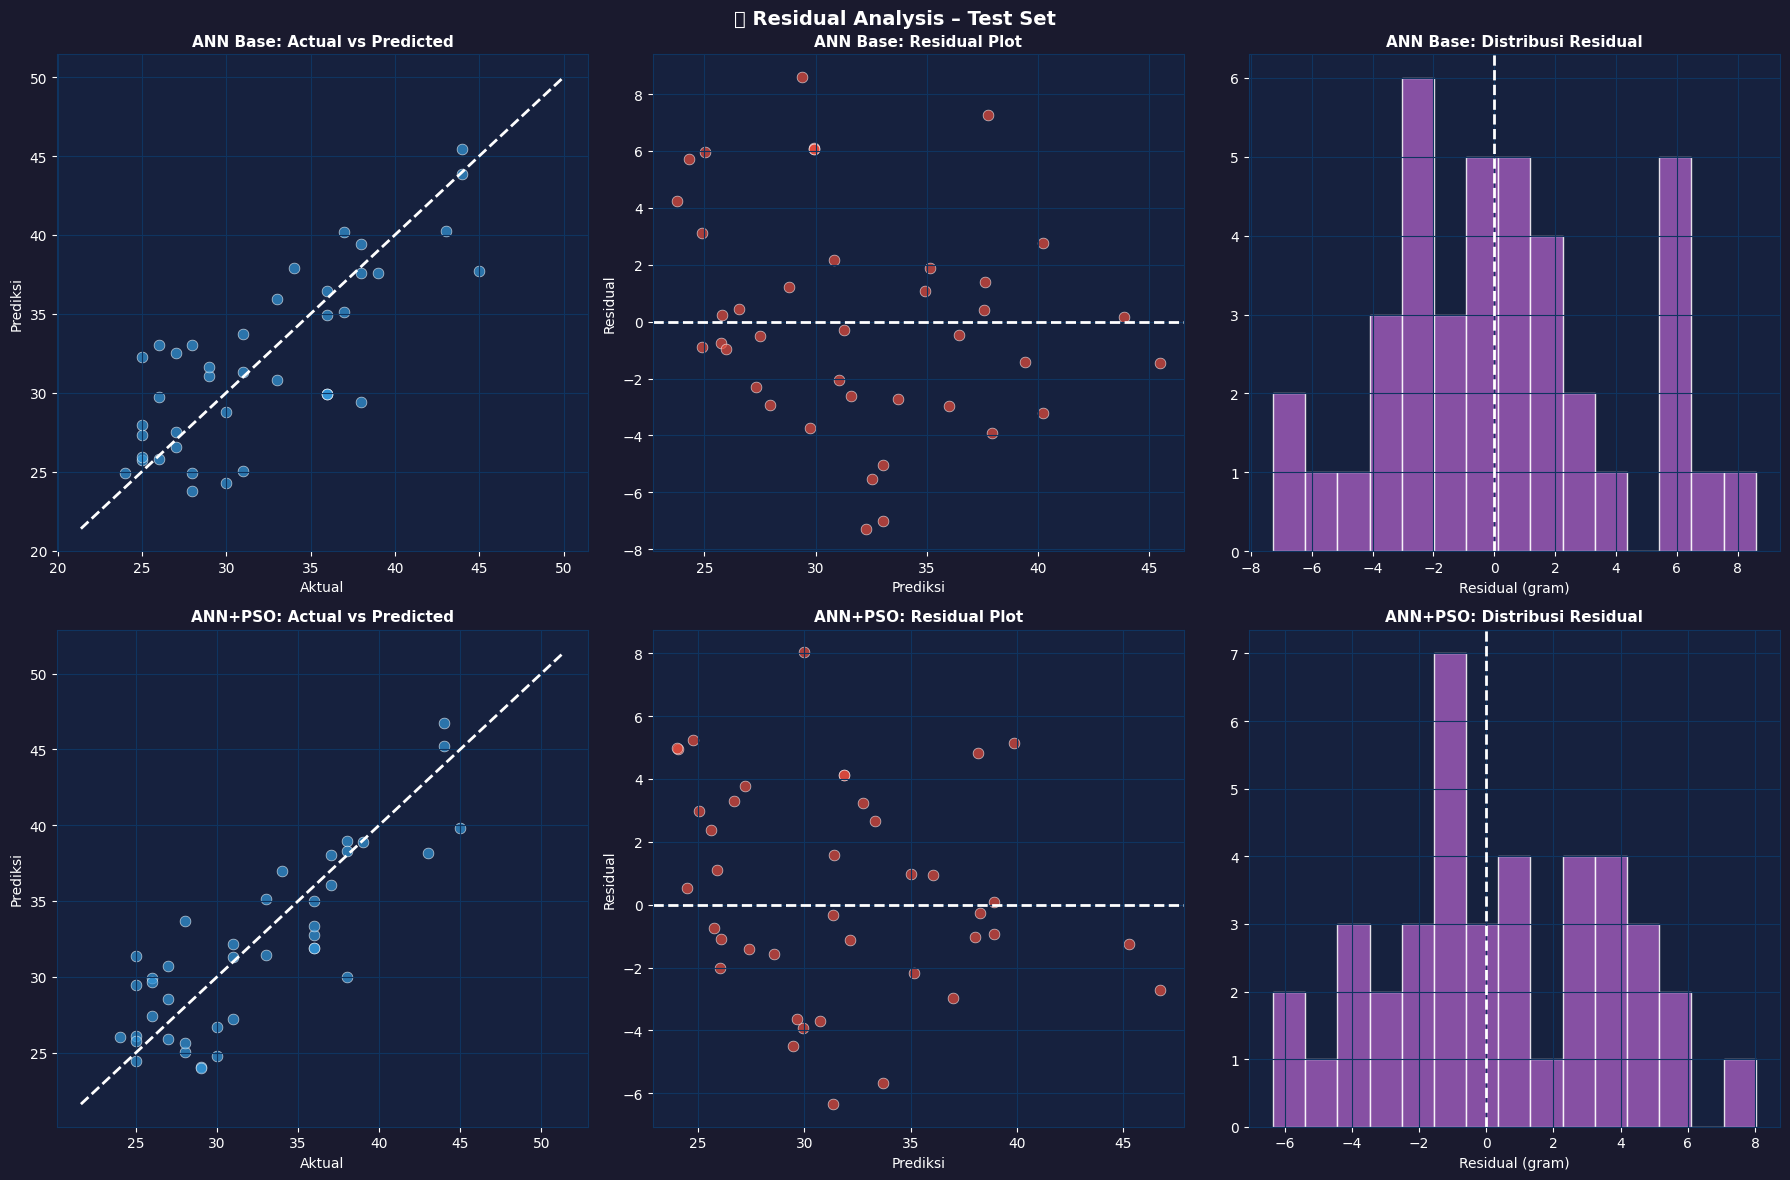

✅ Simpan → output/plots/residual_plot.png


In [6]:
# Residual analysis pada test set
models = {}
if ann_base:
    models['ANN Base'] = ann_base
if ann_pso:
    models['ANN+PSO']  = ann_pso

if not models:
    print('⚠️  Tidak ada model tersimpan! Jalankan NB04 & NB05 dulu.')
else:
    fig, axes = plt.subplots(len(models), 3, figsize=(18, 6 * len(models)))
    if len(models) == 1:
        axes = axes.reshape(1, -1)
    fig.suptitle('🔍 Residual Analysis – Test Set', fontsize=14, fontweight='bold', color='white')

    for row_i, (name, model) in enumerate(models.items()):
        yp    = model.predict(X_test_s)
        resid = y_test - yp

        # Actual vs Predicted
        axes[row_i, 0].scatter(y_test, yp, alpha=0.7, s=60, color='#3498DB', edgecolors='white', lw=0.5)
        lim = [min(y_test.min(), yp.min())*0.9, max(y_test.max(), yp.max())*1.1]
        axes[row_i, 0].plot(lim, lim, 'w--', lw=2)
        axes[row_i, 0].set_title(f'{name}: Actual vs Predicted', fontsize=11, fontweight='bold')
        axes[row_i, 0].set_xlabel('Aktual'); axes[row_i, 0].set_ylabel('Prediksi')

        # Residual scatter
        axes[row_i, 1].scatter(yp, resid, alpha=0.7, s=60, color='#E74C3C', edgecolors='white', lw=0.5)
        axes[row_i, 1].axhline(0, color='white', ls='--', lw=2)
        axes[row_i, 1].set_title(f'{name}: Residual Plot', fontsize=11, fontweight='bold')
        axes[row_i, 1].set_xlabel('Prediksi'); axes[row_i, 1].set_ylabel('Residual')

        # Residual histogram
        axes[row_i, 2].hist(resid, bins=15, color='#9B59B6', edgecolor='white', alpha=0.85)
        axes[row_i, 2].axvline(0, color='white', ls='--', lw=2)
        axes[row_i, 2].set_title(f'{name}: Distribusi Residual', fontsize=11, fontweight='bold')
        axes[row_i, 2].set_xlabel('Residual (gram)')

    plt.tight_layout()
    plt.savefig(f'{BASE_DIR}/output/plots/residual_plot.png', dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
    plt.show()
    print('✅ Simpan → output/plots/residual_plot.png')

In [7]:
# Detail prediksi per sampel
best_model = ann_pso if ann_pso else ann_base

if best_model:
    y_pred_best = best_model.predict(X_test_s)
    df_pred = pd.DataFrame({
        'Aktual (g)': y_test,
        'Prediksi (g)': y_pred_best.round(2),
        'Error (g)': (y_test - y_pred_best).round(2),
        '|Error| (g)': np.abs(y_test - y_pred_best).round(2),
        'MAPE (%)': (np.abs(y_test - y_pred_best) / (y_test + 1e-10) * 100).round(2),
    }).sort_values('|Error| (g)')

    print('📋 DETAIL PREDIKSI TEST SET (sorted by |Error|):')
    print(df_pred.to_string(index=False))

    # Simpan ke CSV
    df_pred.to_csv(f'{BASE_DIR}/output/evaluation_report.csv', index=False)
    print(f'\n✅ Laporan disimpan → output/evaluation_report.csv')

📋 DETAIL PREDIKSI TEST SET (sorted by |Error|):
 Aktual (g)  Prediksi (g)  Error (g)  |Error| (g)  MAPE (%)
       39.0         38.90       0.10         0.10      0.25
       38.0         38.27      -0.27         0.27      0.70
       31.0         31.33      -0.33         0.33      1.06
       25.0         24.47       0.53         0.53      2.11
       25.0         25.75      -0.75         0.75      2.98
       38.0         38.94      -0.94         0.94      2.47
       37.0         36.06       0.94         0.94      2.53
       36.0         35.01       0.99         0.99      2.75
       37.0         38.01      -1.01         1.01      2.74
       25.0         26.08      -1.08         1.08      4.30
       27.0         25.88       1.12         1.12      4.14
       31.0         32.13      -1.13         1.13      3.65
       44.0         45.25      -1.25         1.25      2.84
       26.0         27.42      -1.42         1.42      5.44
       27.0         28.56      -1.56         1.56   

In [8]:
best_model_name = 'ANN+PSO' if ann_pso else 'ANN Base'
best_m = cv_pso if ann_pso else cv_base

print('=' * 60)
print('✅ NOTEBOOK 06 – EVALUASI SELESAI!')
print('=' * 60)
print(f'  Model Terbaik: {best_model_name}')
print()
print('  5-Fold Cross Validation Results (mean ± std):')
for m in ['MAE', 'RMSE', 'R2', 'MAPE']:
    unit = 'g' if m in ['MAE','RMSE'] else ('% ' if m == 'MAPE' else '  ')
    print(f'    {m:>6}: {best_m[m].mean():.4f} ± {best_m[m].std():.4f} {unit}')
print()
print('  File output:')
for f in ['output/plots/cv_evaluation.png',
           'output/plots/residual_plot.png',
           'output/evaluation_report.csv']:
    print(f'    ✅ {f}')
print()
print('📌 Lanjut → 07_Final_Pipeline.ipynb (demo presentasi)')

✅ NOTEBOOK 06 – EVALUASI SELESAI!
  Model Terbaik: ANN+PSO

  5-Fold Cross Validation Results (mean ± std):
       MAE: 4.0299 ± 1.1380 g
      RMSE: 5.0872 ± 1.4584 g
        R2: 0.1003 ± 0.6147   
      MAPE: 13.2441 ± 3.5851 % 

  File output:
    ✅ output/plots/cv_evaluation.png
    ✅ output/plots/residual_plot.png
    ✅ output/evaluation_report.csv

📌 Lanjut → 07_Final_Pipeline.ipynb (demo presentasi)
